Plot Figure 2b
--

In [1]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt

from scipy.stats import t
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D

from config import IUMFIGDIR
from utils.stats import welch_stat, welch_dof, welch_test
from IUM.make_anomalies.twb.make_twb_radius_ctrl_edge_rm import load_twb_radius_ctrl_edge_rm
from IUM.make_anomalies.twb.make_twb_radius_pert_edge_rm import load_twb_radius_pert_edge_rm

In [3]:
var = 'twb'
res = 0.5
value = 0.3
value_pert = 1.
lengths = [25, 30, 35, 50, 75, 100, 125, 150]
u = 4.
env = 'stable'
date = '10010101'
time = 15
window = 3

In [5]:
vals_mean_r = {}
vals_std_r = {}
rs_max = {}
ts_max = {}

for length in lengths:
    print('\n>> %i km <<'%length)

    d = - length / 4  # centre-edge mid-point (downwind)
    data = load_twb_radius_pert_edge_rm(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, window=window, distance=d)

    out_mean = {}
    out_std = {}

    for r, vals in data.items():
        out_mean[r] = vals[0].max().values
        out_std[r] = vals[1].max().values

    vals_mean_r[length] = out_mean
    vals_std_r[length] = out_std

    print(vals_mean_r[length][5.])  # [length/2])

data_dry = load_twb_radius_ctrl_edge_rm(res=res, variable=var, value=value, u=u, env=env, date=date, window=window, distance=20.)
data_wet = load_twb_radius_ctrl_edge_rm(res=res, variable=var, value=value_pert, u=u, env=env, date=date, window=window, distance=20.)

vals_mean_dry = np.asarray([data_dry[r][0].max().values for r in list(data_dry.keys())])  # isel(time=time-1)
vals_std_dry = np.asarray([data_dry[r][1].max().values for r in list(data_dry.keys())])
vals_mean_wet = np.asarray([data_wet[r][0].max().values for r in list(data_wet.keys())])
vals_std_wet = np.asarray([data_wet[r][1].max().values for r in list(data_wet.keys())])

print('UWET mean max: %.2f\nUDRY mean max: %.2f'%(vals_mean_wet.mean(), vals_mean_dry.mean()))


>> 25 km <<
29.58244658119659

>> 30 km <<
30.009747634069402

>> 35 km <<
30.305128205128206

>> 50 km <<
30.409390115667712

>> 75 km <<
30.019925213675215

>> 100 km <<
29.630767613038913

>> 125 km <<
29.333472222222227

>> 150 km <<
29.23583596214511
UWET mean max: 29.10
UDRY mean max: 25.88


In [8]:
rs = list(data_dry.keys())

for length in lengths:
    print('\n>> %i km <<'%length)

    for ir, r in enumerate(rs):
        area = math.pi * (r**2)
        n = area / (res**2)

        mean_pert = vals_mean_r[length][r]
        std_pert = vals_std_r[length][r]

        mean_wet = vals_mean_wet[ir]
        std_wet = vals_std_wet[ir]

        tstat = welch_stat(mean_pert, mean_wet, std_pert, std_wet, n, n)
        dof = welch_dof(std_pert, std_wet, n, n)

        test = welch_test(tstat, dof, 0.05)
        if test == False:
            print((r, test), end=' : ', flush=True)


>> 25 km <<
(11.0, False) : (11.5, False) : 
>> 30 km <<
(13.0, False) : 
>> 35 km <<
(18.0, False) : 
>> 50 km <<
(21.5, False) : 
>> 75 km <<
(28.5, False) : 
>> 100 km <<
(28.5, False) : 
>> 125 km <<
(23.5, False) : (24.0, False) : (24.5, False) : 
>> 150 km <<
(15.5, False) : (16.0, False) : 

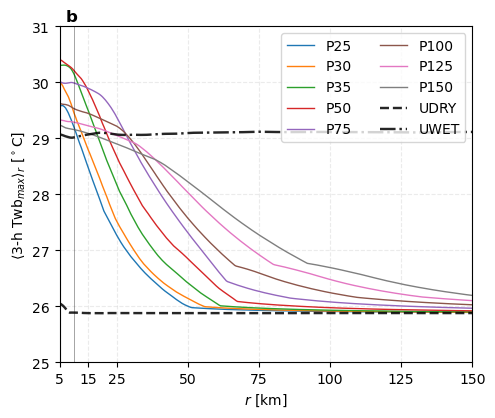

In [9]:
rs = np.asarray(list(data.keys()))

xtcks = np.arange(25, 150+25, 25)
xtcks = np.concatenate([[rs[0]], [15], xtcks])
xtcks.sort()
xtlbs = [int(xt) for xt in xtcks]

if var == 'twb':
    var_ = 'Twb'
    ylims = (25., 31.)
    flab = 'b'
elif var == 'hi':
    var_ = 'HI'
    ylims = (41., 51.)
    flab = ''

l = Line2D([0, 1], [0, 0], color='k', lw=1, ls='--', alpha=0.8)


fig, ax = plt.subplots()

plt.subplots_adjust(top=0.95, right=0.95)

for length in lengths:  # vals in vals_r.items():
    length_ = length / 2
    vals_mean = vals_mean_r[length]
    vals_std = vals_std_r[length]

    ys = np.asarray(list(vals_mean.values())).flatten()
    ys_ = np.asarray(list(vals_std.values())).flatten() / 2

    p = ax.plot(rs, ys, lw=1., label='P%i'%length)
    col = p[0].get_color()

p_dry = ax.plot(rs, vals_mean_dry, lw=1.75, color='k', alpha=0.85, ls='--', label='UDRY')
p_wet = ax.plot(rs, vals_mean_wet, lw=1.75, color='k', alpha=0.85, ls='-.', label='UWET')

ax.axvline(10., 0, 1, c='k', lw=0.5, alpha=0.5)

ax.text(0.015, 1.015, flab, weight='bold', fontsize=12, transform=ax.transAxes)
ax.set_xticks(xtcks)
ax.set_xticklabels(xtlbs)
ax.set_xlim(rs[0], rs[-1])
ax.set_xlabel('$r$ [km]')
ax.set_ylim(ylims)
ax.set_ylabel("$\\langle$%i-h %s$_{max}\\rangle_{r}$ [$^\circ$C]"%(window, var_))
ax.grid(True, ls='--', alpha=0.25)

hs, ls = ax.get_legend_handles_labels()
hs = hs + [l]

ax.legend(handles=hs, labels=ls, loc='upper right', ncol=2)

fig.set_size_inches(5., 4.)